In [ ]:
from google.colab import files
uploaded = files.upload()

Saving content 2.jpg to content 2.jpg
Saving style 2.jpg to style 2.jpg


In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import models, transforms
from PIL import Image
import matplotlib.pyplot as plt

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [ ]:
def load_image(image_path, size=400):
    image = Image.open(image_path)

    transform = transforms.Compose([
        transforms.Resize((size, size)),
        transforms.ToTensor()
    ])

    image = transform(image).unsqueeze(0)
    return image.to(device)

content = load_image("content 2.jpg")
style = load_image("style 2.jpg")

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

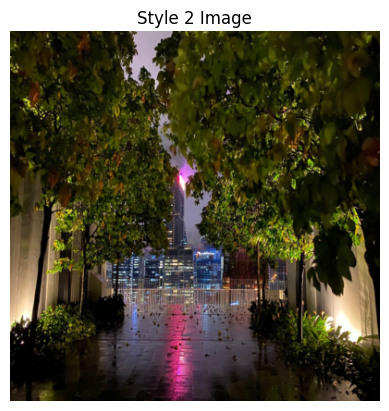

In [ ]:
def imshow(tensor, title=None):
    image = tensor.clone().detach().cpu().squeeze(0)
    image = transforms.ToPILImage()(image)
    plt.imshow(image)
    if title:
        plt.title(title)
    plt.axis("off")

imshow(content, "Content 2 Image")
imshow(style, "Style 2 Image")

In [ ]:
vgg = models.vgg19(pretrained=True).features.to(device).eval()

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=VGG19_Weights.IMAGENET1K_V1`. You can also use `weights=VGG19_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/vgg19-dcbb9e9d.pth" to /root/.cache/torch/hub/checkpoints/vgg19-dcbb9e9d.pth


100%|██████████| 548M/548M [00:07<00:00, 78.1MB/s]


In [ ]:
content_layers = ['21']  # deeper layer
style_layers = ['0','5','10','19','28']

In [ ]:
def get_features(image, model):
    layers = {}
    x = image

    for name, layer in model._modules.items():
        x = layer(x)
        if name in content_layers:
            layers['content'] = x
        if name in style_layers:
            layers[name] = x

    return layers

In [ ]:
def gram_matrix(tensor):
    b, c, h, w = tensor.size()
    tensor = tensor.view(c, h*w)
    gram = torch.mm(tensor, tensor.t())
    return gram

In [ ]:
target = content.clone().requires_grad_(True)

In [ ]:
optimizer = optim.Adam([target], lr=0.003)

In [ ]:
steps = 300

for i in range(steps):
    target_features = get_features(target, vgg)
    content_features = get_features(content, vgg)
    style_features = get_features(style, vgg)

    content_loss = torch.mean((target_features['content'] - content_features['content'])**2)

    style_loss = 0
    for layer in style_layers:
        target_gram = gram_matrix(target_features[layer])
        style_gram = gram_matrix(style_features[layer])
        style_loss += torch.mean((target_gram - style_gram)**2)

    total_loss = content_loss + 1e6 * style_loss

    optimizer.zero_grad()
    total_loss.backward()
    optimizer.step()

    if i % 50 == 0:
        print(f"Step {i}, Loss {total_loss.item()}")

Step 0, Loss 40621825851392.0
Step 50, Loss 7032634081280.0
Step 100, Loss 2748827303936.0
Step 150, Loss 1161648406528.0
Step 200, Loss 583219675136.0
Step 250, Loss 372879360000.0
